In [1]:
import pandas as pd

# Load Plant 1's generation data
gen_data = pd.read_csv('../data/Plant_1_Generation_Data.csv')

# Look at the first few rows
gen_data.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [2]:
# How many unique inverters (source keys) does Plant 1 have?
print("Number of inverters:", gen_data['SOURCE_KEY'].nunique())

# What's the date range?
print("First timestamp:", gen_data['DATE_TIME'].min())
print("Last timestamp:", gen_data['DATE_TIME'].max())

# Check for missing values
gen_data.isnull().sum()

Number of inverters: 22
First timestamp: 01-06-2020 00:00
Last timestamp: 31-05-2020 23:45


DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64

In [3]:
gen_data['DATE_TIME'] = pd.to_datetime(gen_data['DATE_TIME'], format='%d-%m-%Y %H:%M')
gen_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE_TIME    68778 non-null  datetime64[us]
 1   PLANT_ID     68778 non-null  int64         
 2   SOURCE_KEY   68778 non-null  str           
 3   DC_POWER     68778 non-null  float64       
 4   AC_POWER     68778 non-null  float64       
 5   DAILY_YIELD  68778 non-null  float64       
 6   TOTAL_YIELD  68778 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 4.7 MB


Matplotlib is building the font cache; this may take a moment.


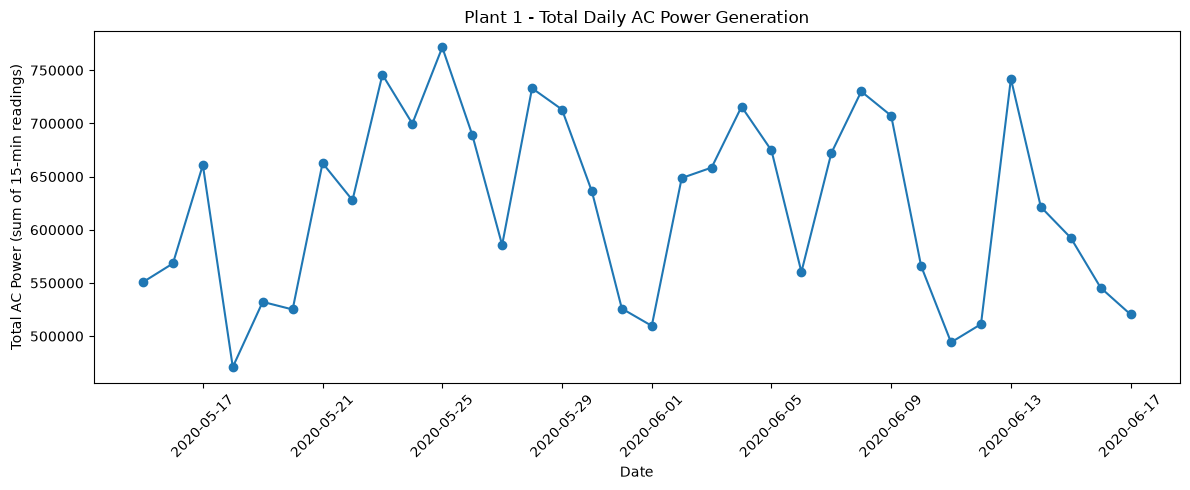

In [4]:
import matplotlib.pyplot as plt

# Add a "date only" column (without the time) so we can group by day
gen_data['DATE'] = gen_data['DATE_TIME'].dt.date

# Sum AC_POWER across all inverters, grouped by day
daily_total = gen_data.groupby('DATE')['AC_POWER'].sum()

# Plot it
plt.figure(figsize=(12, 5))
plt.plot(daily_total.index, daily_total.values, marker='o')
plt.title('Plant 1 - Total Daily AC Power Generation')
plt.xlabel('Date')
plt.ylabel('Total AC Power (sum of 15-min readings)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
